### ДЗ 1 - постановка задачи, метрика, EDA

Датасет: Breast Cancer Wisconsin (Diagnostic) - таблица с измерениями опухоли и диагнозом.

В работе:
- формулирую бизнес-задачу и ML-задачу;
- выбираю метрику и обосновываю её;
- делаю EDA (статистики, распределения, выбросы, связи и корреляции) и краткие выводы.


## 1) Постановка задачи

### Бизнес-постановка
Представим, что в клинике есть поток пациентов с первичными измерениями опухоли. Хочется быстро понять: кого отправлять на более срочное/углублённое обследование, а кого можно вести в стандартном режиме.

Самая неприятная ситуация - когда система говорит “всё нормально”, а на самом деле случай злокачественный. То есть ошибка “пропустить M” дороже, чем “перестраховаться и отправить на дообследование”.

### ML-постановка
Это бинарная классификация: по признакам измерений опухоли (столбцы вида `*_mean`, `*_se`, `*_worst`) предсказать `diagnosis`:
- `M` - malignant (злокачественная)
- `B` - benign (доброкачественная)

**Объект**: одна строка = один пациент/обследование.

**Важно про `id`**: это просто идентификатор записи, он не несёт медицинского смысла - в признаки его не берём.


In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

print("OK")

OK


## Загрузка данных



In [ ]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

FEATURE_COLS = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean",
    "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se", "concave points_se",
    "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst", "concave points_worst",
    "symmetry_worst", "fractal_dimension_worst",
]
COLUMN_NAMES = ["id", "diagnosis"] + FEATURE_COLS

df = pd.read_csv(DATA_URL, header=None, names=COLUMN_NAMES).dropna(axis=1, how="all")
print("Source:", DATA_URL, df.shape)
df.head()

Source: https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2) Выбор и обоснование метрики

В данной постановке медицинской задачи ошибки имеют разную цену.

 - FN (предсказали B, а на самом деле M) - более критичная ошибка, потому что есть риск пропуска злокачественного случая.
 - FP (предсказали M, а на самом деле B) чаще означает лишнее дообследование.

Поэтому как основную метрику логично использовать recall по классу M.

Если нужна одна агрегированная метрика с приоритетом полноты, можно использовать F2.

Дополнительно стоит контролировать precision(M), чтобы не получать слишком много ложных тревог.

## 3) EDA

План:

- проверить размер данных, типы столбцов и пропуски;
- посмотреть баланс классов `M/B`;
- построить распределения признаков и сравнить `M` vs `B`;
- посмотреть выбросы;
- посмотреть связи признаков и корреляции.

После каждого блока - короткие выводы: что заметила и почему это может быть важно.


In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter

In [ ]:
junk = [c for c in df.columns if str(c).startswith("Unnamed") or df[c].isna().all()]
if junk:
    df = df.drop(columns=junk)
    print("Удалены неинформативные столбцы:", junk)
else:
    print("Лишних пустых / Unnamed столбцов не найдено - таблица уже в рабочем виде.")

missing = df.isna().mean().sort_values(ascending=False)
n_bad = int((missing > 0).sum())
print(f"Столбцов с пропусками (доля NaN > 0): {n_bad}")
missing[missing > 0].to_frame("missing_rate")


Лишних пустых / Unnamed столбцов не найдено - таблица уже в рабочем виде.
Столбцов с пропусками (доля NaN > 0): 0


,missing_rate


**Выводы (пропуски):**

- Сырой файл UCI мы читаем без «шапки» в файле и сами задаём имена столбцов, при загрузке сразу отбрасываются полностью пустые столбцы (`dropna(axis=1, how="all")`). В таком виде нет фиктивной колонки вроде `Unnamed: 32`, которая возникала у меня, если тот же набор просто сохранить в CSV.
- Отдельным шагом (на всякий случай) выше удаляются `Unnamed:*` и полностью пустые столбцы, если они появились при другом способе импорта - это защищает пайплайн, не ломая текущую загрузку.
- По всем оставшимся столбцам пропусков нет (`missing_rate = 0` везде), поэтому на EDA не нужна стратегия заполнения пропусков - можно переходить к балансу классов и распределениям.


In [ ]:
target_col = "diagnosis"
assert target_col in df.columns

class_counts = df[target_col].value_counts(dropna=False)
class_rates = (class_counts / len(df)).round(4)
pd.DataFrame({"count": class_counts, "rate": class_rates})

,count,rate
diagnosis,,
B,357,0.6274
M,212,0.3726


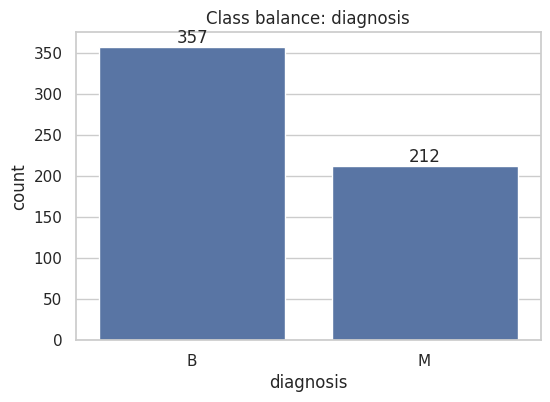

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=target_col, order=class_counts.index)
ax.set_title("Class balance: diagnosis")
ax.bar_label(ax.containers[0])
plt.show()

**Выводы (баланс классов):**

- В данных больше доброкачественных случаев: `B = 357` (≈ 62.7%), злокачественных меньше: `M = 212` (≈ 37.3%). Это умеренный дисбаланс.
- Даже при таком дисбалансе `accuracy` может быть не самой показательной метрикой: она не говорит, сколько злокачественных случаев мы пропустили.
- Для этой задачи важнее не пропускать `M`, поэтому логично ориентироваться на `recall(M)` (и при необходимости на `F2`), а `precision(M)` держать в уме, чтобы не было слишком много ложных тревог.


In [ ]:
id_col = "id" if "id" in df.columns else None

feature_cols = [c for c in df.columns if c not in {target_col, id_col}]
X = df[feature_cols]

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
non_numeric_cols = [c for c in X.columns if c not in numeric_cols]

print("Features:", len(feature_cols))
print("Numeric:", len(numeric_cols))
print("Non-numeric:", non_numeric_cols)

df[numeric_cols].describe().T.head(10)

Features: 30
Numeric: 30
Non-numeric: []


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


**Выводы:**

- В матрицу признаков `X` (без `id` и `diagnosis`) входят только 30 числовых столбцов; отдельных категориальных признаков в `X` нет - цель `diagnosis` категориальная, для модели её кодируют отдельно.

- По describe() видно, что масштабы признаков сильно разные (например, area_mean сотни/тысячи, а smoothness_mean около 0.1) => если дальше обучать модели типа логрег/knn, скорее всего понадобится масштабирование.

- По min/max у части признаков есть широкий разброс, это потом стоит проверить на выбросы

### Распределения признаков (seaborn)



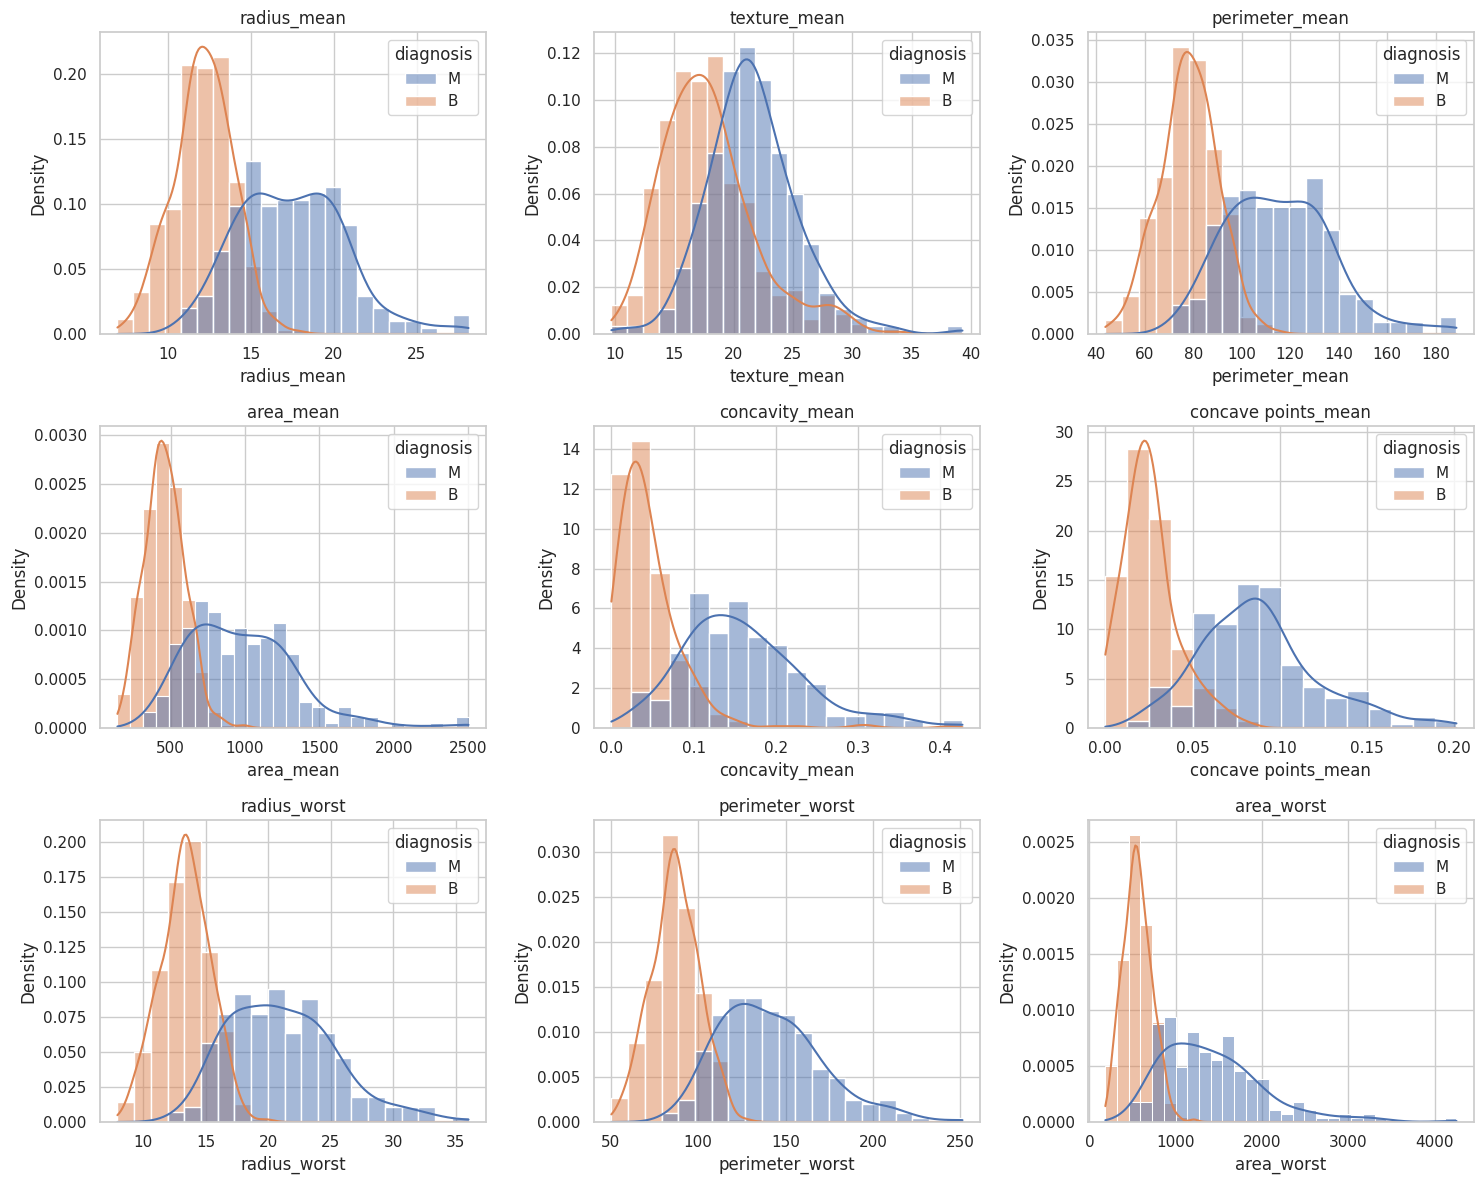

In [ ]:
candidate_plot_cols = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concavity_mean",
    "concave points_mean",
    "radius_worst",
    "perimeter_worst",
    "area_worst",
]
plot_cols = [c for c in candidate_plot_cols if c in df.columns]

n = len(plot_cols)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_cols):
    ax = axes[i]
    sns.histplot(data=df, x=col, hue=target_col, kde=True, stat="density", common_norm=False, ax=ax)
    ax.set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

**Выводы (распределения):**

- На большинстве признаков распределение M заметно сдвинуто вправо, а B - левее.

- То есть у M обычно значения больше, хотя пик у B часто выше. У B распределение часто более узкое, поэтому плотность в центре больше и пик получается выше.

- Везде есть перекрытие M и B: одним признаком идеально не разделить, но по нескольким признакам вместе разделение должно быть заметно лучше.


### Выбросы (boxplot)

Boxplot помогут увидеть:
- есть ли выбросы/длинные хвосты;
- отличаются ли значения признака у `M` и `B`.

Выбросы не обязательно удалять: иногда это редкие, но реальные наблюдения.


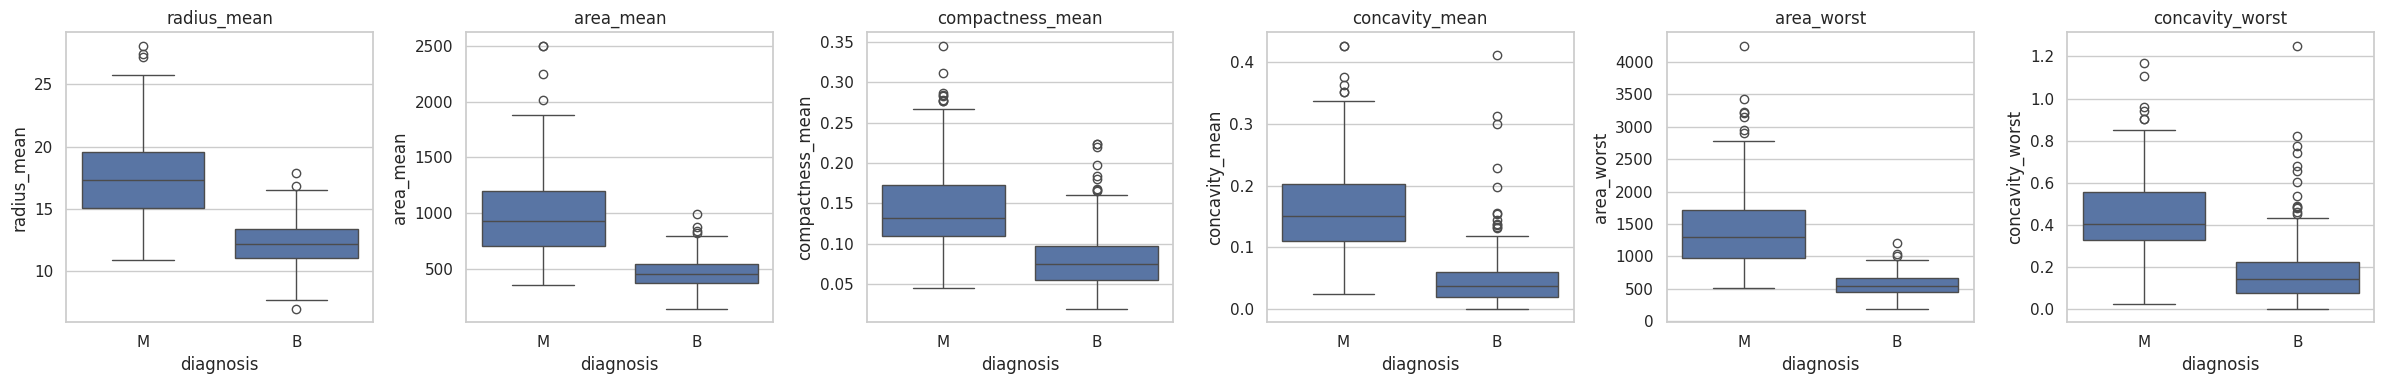

In [ ]:
box_cols = [c for c in ["radius_mean", "area_mean", "compactness_mean", "concavity_mean", "area_worst", "concavity_worst"] if c in df.columns]

fig, axes = plt.subplots(1, len(box_cols), figsize=(4 * len(box_cols), 4), sharey=False)
if len(box_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.cbook import boxplot_stats

outlier_cols = box_cols

for col in outlier_cols:
    fliers = boxplot_stats(df[col].dropna()).pop(0)["fliers"]
    print(f"{col}: outliers_count={len(fliers)}")
    if len(fliers) > 0:
        print(f"  пример значений: {np.sort(fliers)[:10]}")


radius_mean: outliers_count=14
  пример значений: [22.01 22.27 23.09 23.21 23.27 23.29 23.51 24.25 24.63 25.22]
area_mean: outliers_count=25
  пример значений: [1335. 1347. 1364. 1384. 1386. 1404. 1407. 1419. 1479. 1482.]
compactness_mean: outliers_count=16
  пример значений: [0.2293 0.2363 0.2364 0.2396 0.2413 0.2458 0.2576 0.2665 0.2768 0.277 ]
concavity_mean: outliers_count=18
  пример значений: [0.2871 0.2914 0.3001 0.3003 0.313  0.3174 0.3176 0.3189 0.3201 0.3339]
area_worst: outliers_count=35
  пример значений: [1938. 1946. 1956. 1972. 1986. 2009. 2010. 2019. 2022. 2027.]
concavity_worst: outliers_count=12
  пример значений: [0.7892 0.8216 0.8402 0.8488 0.8489 0.9019 0.9034 0.9387 0.9608 1.105 ]


**Выводы (выбросы):**

- Выбросы есть во всех выбранных признаках, но их количество разное:
  - `area_worst` - 35
  - `area_mean` - 25
  - `concavity_mean` - 18
  - `compactness_mean` - 16
  - `radius_mean` - 14
  - `concavity_worst` - 12
- По примерам значений видно, что выбросы в основном лежат в правом хвосте.
- Это согласуется с boxplot: у класса `M` медианы и диапазоны выше, и именно там чаще встречаются экстремальные значения.
- При дальнейшем моделировании это стоит учитывать: либо использовать устойчивые к выбросам подходы, либо аккуратно ограничивать хвосты и проверять, как это влияет на качество.


### Связи признаков (scatter)




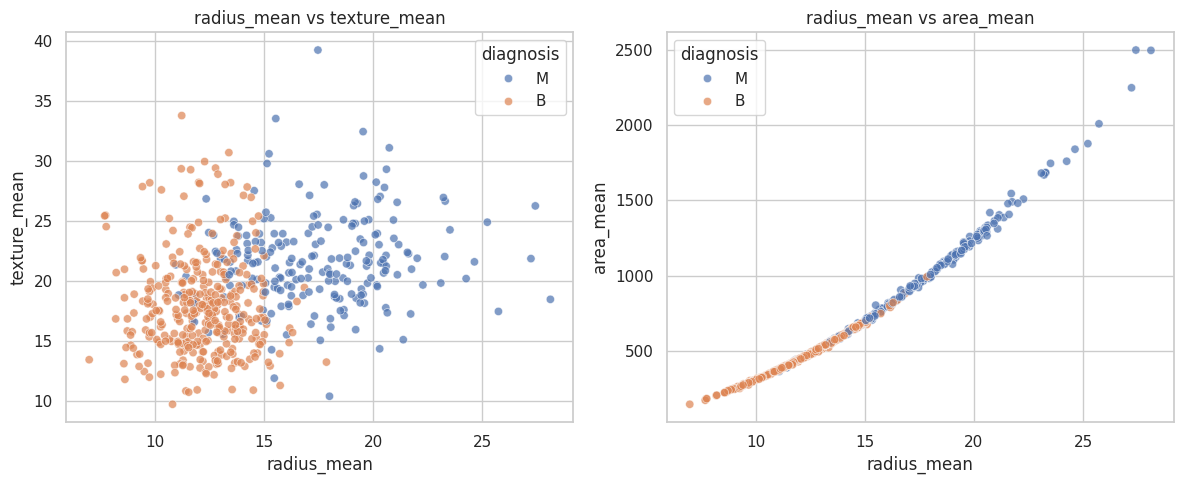

In [ ]:
pair_1 = ("radius_mean", "texture_mean")
pair_2 = ("radius_mean", "area_mean")
pairs = [pair_1, pair_2]
pairs = [p for p in pairs if p[0] in df.columns and p[1] in df.columns]

fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5))
if len(pairs) == 1:
    axes = [axes]

for ax, (xcol, ycol) in zip(axes, pairs):
    sns.scatterplot(data=df, x=xcol, y=ycol, hue=target_col, alpha=0.7, ax=ax)
    ax.set_title(f"{xcol} vs {ycol}")

plt.tight_layout()
plt.show()

**Выводы (связи признаков):**

- На графике radius_mean vs texture_mean классы частично разделяются, но есть зона пересечения (особенно при radius_mean примерно 13-16).
- На графике radius_mean vs area_mean видна очень сильная положительная связь: при росте radius_mean растёт area_mean; классы здесь разделяются лучше, но пересечение всё равно есть.
- В целом пары признаков полезны для различения M и B, но полного разделения одним-двумя признаками нет, значит для итогового решения лучше использовать несколько признаков одновременно.

### Корреляции (heatmap)

Корреляции нужны, чтобы понять, есть ли сильно похожие признаки (которые дублируют друг друга). В этом датасете такое возможно, потому что многие признаки связаны по смыслу.


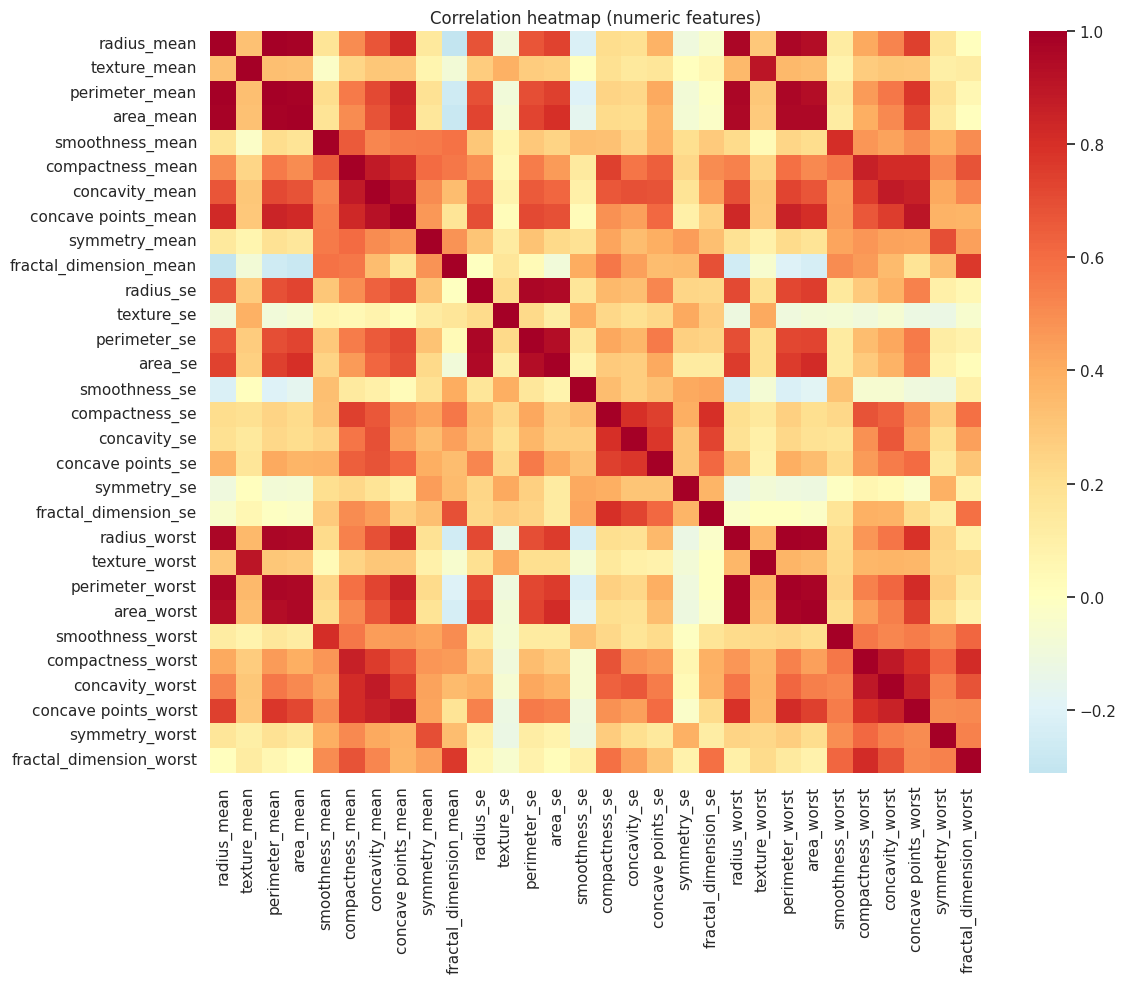

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="RdYlBu_r", center=0, cbar=True)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

**Выводы (корреляции):**

- На тепловой карте хорошо видны группы признаков с высокой положительной корреляцией. Самый заметный блок - `radius_*`, `perimeter_*`, `area_*` (и между `mean` и `worst` версиями этих признаков).
- Также выражены связи между `compactness_*`, `concavity_*` и `concave points_*`.
- Это означает, что часть признаков частично дублирует друг друга (есть избыточность), поэтому при дальнейшем моделировании можно рассмотреть отбор признаков или регуляризацию.


## Plotly (интерактивные графики)

Ниже пара интерактивных графиков на plotly.


In [ ]:
plotly_x = "radius_mean" if "radius_mean" in df.columns else numeric_cols[0]
plotly_y = "texture_mean" if "texture_mean" in df.columns else numeric_cols[1]

fig = px.scatter(
    df,
    x=plotly_x,
    y=plotly_y,
    color=target_col,
    title=f"Interactive scatter: {plotly_x} vs {plotly_y}",
    opacity=0.7,
)
fig.show()

In [ ]:
hist_col = "area_worst" if "area_worst" in df.columns else numeric_cols[0]

fig = px.histogram(
    df,
    x=hist_col,
    color=target_col,
    marginal="box",
    barmode="overlay",
    opacity=0.6,
    title=f"Interactive histogram: {hist_col} by diagnosis",
)
fig.show()

## Итоговые выводы


- В датасете **569** строк, **32** столбца: `id`, `diagnosis` и **30** числовых признаков. Загрузка с UCI с явными именами колонок даёт таблицу без лишнего пустого хвоста; при других экспортах тот же датасет иногда приходит с `Unnamed:*` - такие столбцы убираются до анализа.
- Таргет - `diagnosis` (категория `M`/`B`), `id` - только идентификатор (в признаки не берём). Кроме `id` и `diagnosis`, все признаковые столбцы - числовые.
- Баланс классов: B = 357 (62.74%), M = 212 (37.26%).
- Дисбаланс умеренный, поэтому ориентироваться только на accuracy нежелательно.
- Для этой задачи приоритет - не пропускать M, поэтому основная метрика: recall(M). Дополнительно полезно смотреть F2 и precision(M).
- По распределениям видно, что по ряду признаков (radius, perimeter, area, concavity, concave points) классы различаются: у M значения чаще смещены к большим.
- По boxplot и подсчёту выбросов выбросы есть во всех выбранных признаках, больше всего в area_worst (35) и area_mean (25); в основном это верхние значения.
- По scatter-графикам:
  - radius_mean vs texture_mean - есть частичное разделение, но заметное пересечение классов;
  - radius_mean vs area_mean - очень сильная положительная связь и более явное разделение, но не идеальное.
- По heatmap видны группы сильно коррелирующих признаков (radius/perimeter/area, а также compactness/concavity/concave points), значит часть признаков частично дублирует информацию.

**Практический вывод:** данные подходят для бинарной классификации, сигнал в признаках есть, но из-за пересечений и коррелирующих признаков модель стоит строить на нескольких признаках сразу и контролировать метрики именно для класса M.
